# Intelligent Real-Time Financial Fraud Detection System



In [ ]:
# Numerical Computation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Handling Imbalanced Dataset
from imblearn.over_sampling import SMOTE

# Ignore Warning Messages
import warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("="*70)
print("Libraries Successfully Imported")
print("="*70)

Libraries Successfully Imported


## 1. Data Loading



In [ ]:
DATA_PATH = '/content/PS_20174392719_1491204439457_log.csv'

df_raw = pd.read_csv(DATA_PATH, dtype={
    'step':'int32','type':'category','amount':'float64','nameOrig':'string',
    'oldbalanceOrg':'float64','newbalanceOrig':'float64','nameDest':'string',
    'oldbalanceDest':'float64','newbalanceDest':'float64','isFraud':'int8','isFlaggedFraud':'int8'})

print('Raw shape:', df_raw.shape)
df_raw.head()


Raw shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [ ]:
fraud_by_type = df_raw.groupby('type', observed=True)['isFraud'].agg(['count','sum'])
fraud_by_type.columns = ['transaction_count', 'fraud_count']
print(fraud_by_type)
print('\nOverall fraud rate: %.5f%%' % (df_raw['isFraud'].mean()*100))


          transaction_count  fraud_count
type                                    
CASH_IN             1399284            0
CASH_OUT            2237500         4116
DEBIT                 41432            0
PAYMENT             2151495            0
TRANSFER             532909         4097

Overall fraud rate: 0.12908%


# Dataset Information

In [ ]:
# =============================================================================
# Dataset Information
# =============================================================================

print("="*70)
print("Dataset Information")
print("="*70)

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
Index: 2770409 entries, 2 to 6362619
Data columns (total 19 columns):
 #   Column                Dtype  
---  ------                -----  
 0   step                  int32  
 1   type                  object 
 2   amount                float64
 3   nameOrig              string 
 4   oldbalanceOrg         float64
 5   newbalanceOrig        float64
 6   nameDest              string 
 7   oldbalanceDest        float64
 8   newbalanceDest        float64
 9   isFraud               int8   
 10  isFlaggedFraud        int8   
 11  hour_of_day           int32  
 12  day                   int64  
 13  errorBalanceOrig      float64
 14  errorBalanceDest      float64
 15  origEmptiedAfter      int64  
 16  destZeroBefore        int64  
 17  amountToBalanceRatio  float64
 18  type_TRANSFER         int64  
dtypes: float64(8), int32(2), int64(4), int8(2), object(1), string(2)
memory usage: 364.6+ MB


### 1.1 Restricting the modelling scope

Fraudulent transactions in PaySim occur **exclusively** within `TRANSFER` and `CASH_OUT`
transaction types (this is confirmed above — `PAYMENT`, `CASH_IN`, and `DEBIT` contain zero
fraud cases). Consistent with prior published work on this dataset, the modelling scope is
restricted to `TRANSFER` and `CASH_OUT` transactions. No fraudulent cases are discarded by
this filtering step.

In [ ]:
df = df_raw[df_raw['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()
df['type'] = df['type'].astype(str)
print('Filtered shape:', df.shape)
print('Fraud rate in filtered set: %.4f%%' % (df['isFraud'].mean()*100))


Filtered shape: (2770409, 11)
Fraud rate in filtered set: 0.2965%


# Missing Value Analysis

In [ ]:
# =============================================================================
# Missing Value Analysis
# =============================================================================

missing = pd.DataFrame(df.isnull().sum())

missing.columns = ["Missing Values"]

missing["Percentage"] = (
    missing["Missing Values"]/len(df)
)*100

display(missing)

,Missing Values,Percentage
step,0,0.0
type,0,0.0
amount,0,0.0
nameOrig,0,0.0
oldbalanceOrg,0,0.0
newbalanceOrig,0,0.0
nameDest,0,0.0
oldbalanceDest,0,0.0
newbalanceDest,0,0.0
isFraud,0,0.0


## 2. Feature Engineering

Two feature families are engineered: **transaction-level (short-horizon) features** describing the current transaction, and **account-consistency features** that expose the balance-tampering signature characteristic of PaySim fraud (the simulator does not update the destination balance correctly on fraudulent transfers).

In [ ]:
df['hour_of_day'] = df['step'] % 24
df['day'] = (df['step'] // 24) + 1

# Balance-consistency error features
df['errorBalanceOrig'] = df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

# Behavioural flags
df['origEmptiedAfter'] = ((df['oldbalanceOrg'] > 0) & (df['newbalanceOrig'] == 0)).astype(int)
df['destZeroBefore'] = ((df['oldbalanceDest'] == 0) & (df['newbalanceDest'] == 0) & (df['amount'] > 0)).astype(int)
df['amountToBalanceRatio'] = df['amount'] / (df['oldbalanceOrg'] + 1)
df['type_TRANSFER'] = (df['type'] == 'TRANSFER').astype(int)

feature_cols = ['step', 'hour_of_day', 'day', 'type_TRANSFER', 'amount',
                 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest',
                 'errorBalanceOrig', 'errorBalanceDest', 'origEmptiedAfter',
                 'destZeroBefore', 'amountToBalanceRatio']

X = df[feature_cols].copy()
y = df['isFraud'].copy()
print('Feature matrix:', X.shape)
X.describe().T


Feature matrix: (2770409, 14)


,count,mean,std,min,25%,50%,75%,max
step,2770409.0,2.420081e+02,1.416191e+02,1.00,155.000000,236.000000,332.00,7.430000e+02
hour_of_day,2770409.0,1.530878e+01,4.004595e+00,0.00,12.000000,16.000000,19.00,2.300000e+01
day,2770409.0,1.044580e+01,5.893392e+00,1.00,7.000000,10.000000,14.00,3.100000e+01
type_TRANSFER,2770409.0,1.923575e-01,3.941525e-01,0.00,0.000000,0.000000,0.00,1.000000e+00
amount,2770409.0,3.175361e+05,8.877897e+05,0.00,82973.540000,171260.930000,306791.18,9.244552e+07
oldbalanceOrg,2770409.0,4.764308e+04,2.513251e+05,0.00,0.000000,303.960000,30997.00,5.958504e+07
newbalanceOrig,2770409.0,1.609190e+04,1.512558e+05,0.00,0.000000,0.000000,0.00,4.958504e+07
oldbalanceDest,2770409.0,1.703551e+06,4.225550e+06,0.00,128073.450000,555709.970000,1735900.15,3.560159e+08
newbalanceDest,2770409.0,2.049734e+06,4.676990e+06,0.00,327289.080000,828053.880000,2122198.45,3.561793e+08
errorBalanceOrig,2770409.0,-2.859850e+05,8.753230e+05,-92445516.64,-279891.160000,-143597.060000,-51853.10,1.000000e-02


### 2.1 Naive rule-based flag check

PaySim ships with a built-in naive business rule, `isFlaggedFraud`, which flags a transfer
only when the amount exceeds 200,000 in a single transaction. This gives a concrete, data-driven
illustration of the problem statement in the proposal (i.e., that simple, static rule-based
systems are inadequate for real-time fraud detection).

In [ ]:
n_flagged = df['isFlaggedFraud'].sum()
n_flagged_correct = ((df['isFlaggedFraud']==1) & (df['isFraud']==1)).sum()
n_total_fraud = df['isFraud'].sum()
print(f'isFlaggedFraud raised {n_flagged} alerts, of which {n_flagged_correct} were true fraud.')
print(f'Recall of the naive rule-based flag: {n_flagged_correct/n_total_fraud*100:.2f}% of {n_total_fraud} fraud cases.')


isFlaggedFraud raised 16 alerts, of which 16 were true fraud.
Recall of the naive rule-based flag: 0.19% of 8213 fraud cases.


## 3. Exploratory Data Analysis

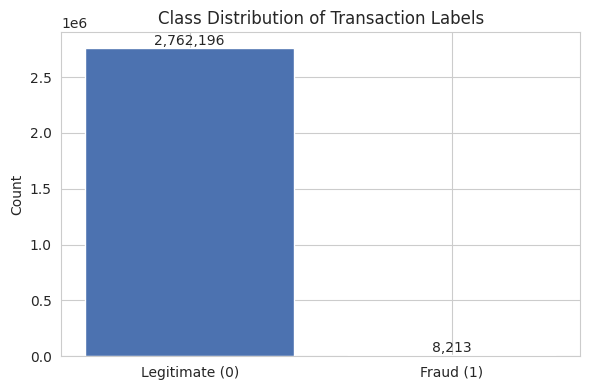

In [ ]:
plt.figure(figsize=(6,4))
counts = y.value_counts().sort_index()
plt.bar(['Legitimate (0)', 'Fraud (1)'], counts.values, color=['#4C72B0', '#C44E52'])
plt.ylabel('Count'); plt.title('Class Distribution of Transaction Labels')
for i, v in enumerate(counts.values):
    plt.text(i, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout(); plt.show()


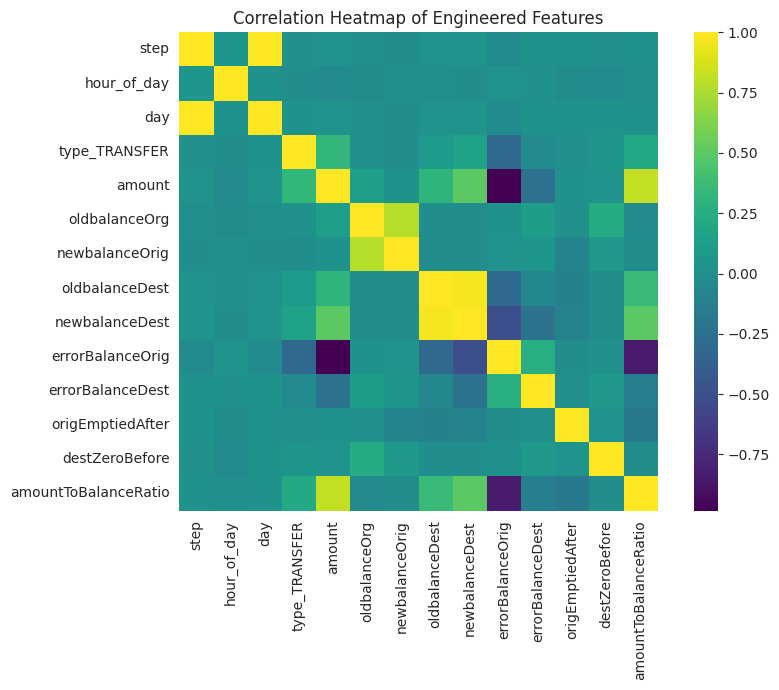

Top correlated feature pairs:
step              day                 0.999600
day               step                0.999600
errorBalanceOrig  amount              0.982838
amount            errorBalanceOrig    0.982838
oldbalanceDest    newbalanceDest      0.970060
newbalanceDest    oldbalanceDest      0.970060
dtype: float64


In [ ]:
plt.figure(figsize=(9,7))
corr = X.corr()
sns.heatmap(corr, cmap='viridis', square=True)
plt.title('Correlation Heatmap of Engineered Features')
plt.tight_layout(); plt.show()

c = corr.where(~np.eye(len(corr), dtype=bool)).abs().unstack().sort_values(ascending=False)
print('Top correlated feature pairs:')
print(c.head(6))


Transaction Type Distribution


,count
type,
CASH_OUT,2237500
TRANSFER,532909


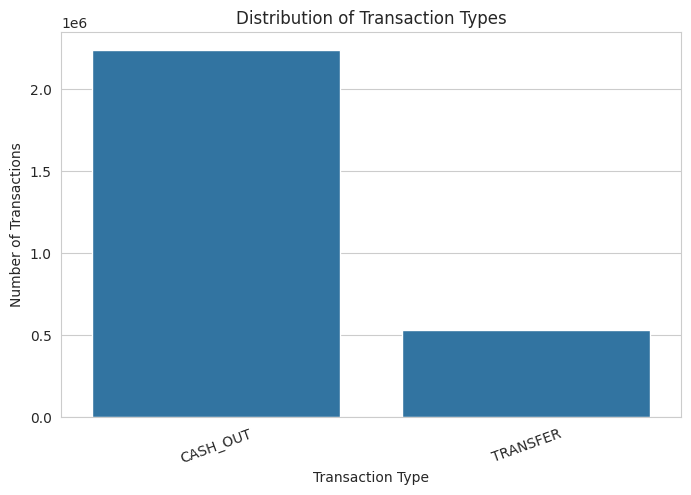

In [ ]:
# =============================================================================
# Transaction Type Distribution
# =============================================================================

print("="*70)
print("Transaction Type Distribution")
print("="*70)

type_counts = df["type"].value_counts()

display(type_counts)

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="type",
    order=df["type"].value_counts().index
)

plt.title("Distribution of Transaction Types")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=20)

plt.show()

# Outlier Examination:

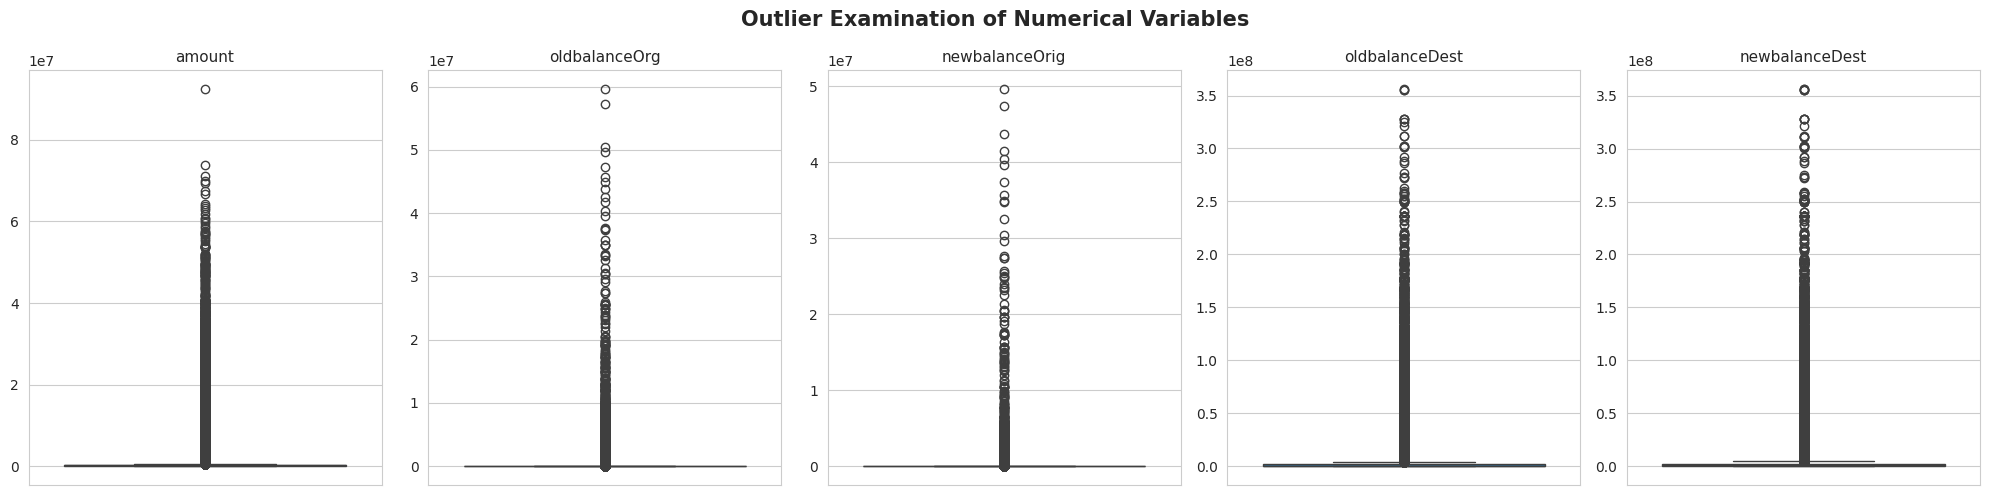

In [42]:
# =============================================================================
# Outlier Examination of Numerical Features
# =============================================================================

numerical_features = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, feature in zip(axes, numerical_features):

    sns.boxplot(
        y=df[feature],
        ax=ax
    )

    ax.set_title(feature, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.suptitle(
    "Outlier Examination of Numerical Variables",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## 4. Train / Test Split and Class-Imbalance Handling



In [43]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print('Train (full):', X_train_full.shape, 'fraud:', y_train_full.sum())
print('Test:', X_test.shape, 'fraud:', y_test.sum())

fraud_idx = y_train_full[y_train_full == 1].index
legit_idx = y_train_full[y_train_full == 0].index
n_fraud = len(fraud_idx)
n_legit_keep = min(len(legit_idx), n_fraud * 3)
legit_sample_idx = np.random.choice(legit_idx, size=n_legit_keep, replace=False)
train_idx = np.concatenate([fraud_idx.values, legit_sample_idx])
np.random.shuffle(train_idx)

X_train = X_train_full.loc[train_idx]
y_train = y_train_full.loc[train_idx]
print('Undersampled train:', X_train.shape, 'fraud ratio: %.3f' % y_train.mean())

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


Train (full): (2216327, 14) fraud: 6570
Test: (554082, 14) fraud: 1643
Undersampled train: (26280, 14) fraud ratio: 0.250


## 5. Pre-Model Feature Importance (Random Forest)

In [48]:
print(X.dtypes)

step                             int32
type                            object
amount                         float64
nameOrig                string[python]
oldbalanceOrg                  float64
newbalanceOrig                 float64
nameDest                string[python]
oldbalanceDest                 float64
newbalanceDest                 float64
isFlaggedFraud                    int8
hour_of_day                      int32
day                              int64
errorBalanceOrig               float64
errorBalanceDest               float64
origEmptiedAfter                 int64
destZeroBefore                   int64
amountToBalanceRatio           float64
type_TRANSFER                    int64
dtype: object


,Feature,Importance
10,errorBalanceOrig,0.320086
14,amountToBalanceRatio,0.286804
3,oldbalanceOrg,0.107602
12,origEmptiedAfter,0.090695
4,newbalanceOrig,0.041791
13,destZeroBefore,0.040329
6,newbalanceDest,0.033559
5,oldbalanceDest,0.021945
11,errorBalanceDest,0.020120
2,amount,0.013663


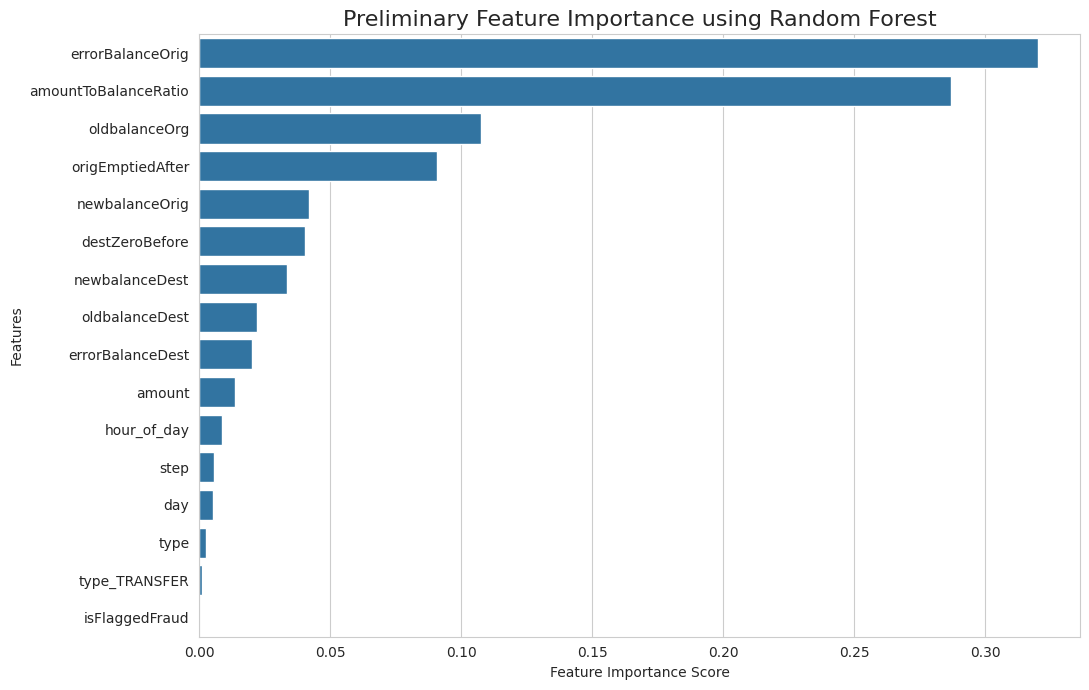

In [49]:
# =============================================================================
# Feature Importance (Pre-Model Insights using Random Forest)
# =============================================================================

from sklearn.ensemble import RandomForestClassifier

# Prepare data
X = df.drop(columns=["isFraud"], errors="ignore").copy()
y = df["isFraud"]

# Encode categorical variable if present
if "type" in X.columns:
    X["type"] = X["type"].map({
        "CASH_OUT": 0,
        "TRANSFER": 1
    })

# Remove customer identifiers
X.drop(columns=["nameOrig", "nameDest"], errors="ignore", inplace=True)

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(X, y)

# Feature Importance
feature_importance = (
    pd.DataFrame({
        "Feature": X.columns,
        "Importance": rf.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

display(feature_importance)

# Plot
plt.figure(figsize=(11,7))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Preliminary Feature Importance using Random Forest", fontsize=16)
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

## 6. Model Development



In [51]:
# =============================================================================
# Feature Scaling for Logistic Regression and Deep Learning Models
# =============================================================================

from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(
    X_train
)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(
    X_test
)

print("Scaled Training Data Shape:", X_train_scaled.shape)
print("Scaled Testing Data Shape :", X_test_scaled.shape)

Scaled Training Data Shape: (26280, 14)
Scaled Testing Data Shape : (554082, 14)


In [52]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(26280, 14)
(554082, 14)
(26280,)
(554082,)


In [54]:


import xgboost as xgb

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier, MLPRegressor

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score
)

# Deep Learning Libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping



# =============================================================================
# Model Evaluation Function
# =============================================================================

results = {}


def evaluate(name, y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)


    roc = roc_auc_score(
        y_true,
        y_prob
    )


    pr_auc = average_precision_score(
        y_true,
        y_prob
    )


    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )


    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )


    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )


    results[name] = {
        "ROC-AUC": roc,
        "PR-AUC": pr_auc,
        "F1-Score": f1,
        "Precision": precision,
        "Recall": recall
    }


    print(
        f"{name}: "
        f"ROC-AUC={roc:.4f} | "
        f"PR-AUC={pr_auc:.4f} | "
        f"F1={f1:.4f} | "
        f"Precision={precision:.4f} | "
        f"Recall={recall:.4f}"
    )


    return y_pred




# =============================================================================
# 1. Logistic Regression Baseline Model
# =============================================================================

lr = LogisticRegression(
    max_iter=500,
    class_weight="balanced",
    random_state=42
)


lr.fit(
    X_train_scaled,
    y_train
)


lr_prob = lr.predict_proba(
    X_test_scaled
)[:,1]


evaluate(
    "Logistic Regression",
    y_test,
    lr_prob
)




# =============================================================================
# 2. Random Forest Ensemble Model
# =============================================================================

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced_subsample"
)


rf.fit(
    X_train,
    y_train
)


rf_prob = rf.predict_proba(
    X_test
)[:,1]


evaluate(
    "Random Forest",
    y_test,
    rf_prob
)




# =============================================================================
# 3. XGBoost Ensemble Model
# =============================================================================

fraud_weight = (
    (y_train == 0).sum()
    /
    (y_train == 1).sum()
)


xgb_model = xgb.XGBClassifier(

    n_estimators=300,

    max_depth=6,

    learning_rate=0.1,

    subsample=0.8,

    colsample_bytree=0.8,

    eval_metric="auc",

    tree_method="hist",

    random_state=42,

    scale_pos_weight=fraud_weight
)



xgb_model.fit(
    X_train,
    y_train
)



xgb_prob = xgb_model.predict_proba(
    X_test
)[:,1]



evaluate(
    "XGBoost Ensemble",
    y_test,
    xgb_prob
)




# =============================================================================
# 4. Deep Neural Network (DNN)
# =============================================================================

dnn = MLPClassifier(

    hidden_layer_sizes=(64,32,16),

    activation="relu",

    solver="adam",

    alpha=1e-4,

    max_iter=200,

    early_stopping=True,

    random_state=42
)



dnn.fit(
    X_train_scaled,
    y_train
)



dnn_prob = dnn.predict_proba(
    X_test_scaled
)[:,1]



evaluate(
    "Deep Neural Network",
    y_test,
    dnn_prob
)




# =============================================================================
# 5. LSTM Deep Learning Model
# =============================================================================

# Convert tabular data into sequence format

X_train_lstm = np.reshape(

    X_train_scaled,

    (
        X_train_scaled.shape[0],
        1,
        X_train_scaled.shape[1]
    )

)


X_test_lstm = np.reshape(

    X_test_scaled,

    (
        X_test_scaled.shape[0],
        1,
        X_test_scaled.shape[1]
    )

)



print(
    "LSTM Input Shape:",
    X_train_lstm.shape
)



lstm_model = Sequential([


    LSTM(
        64,
        input_shape=(
            X_train_lstm.shape[1],
            X_train_lstm.shape[2]
        )
    ),


    Dropout(0.3),


    Dense(
        32,
        activation="relu"
    ),


    Dropout(0.2),


    Dense(
        1,
        activation="sigmoid"
    )

])



lstm_model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["AUC"]

)



early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)



lstm_model.fit(

    X_train_lstm,

    y_train,

    validation_split=0.2,

    epochs=20,

    batch_size=512,

    callbacks=[early_stop],

    verbose=1

)



lstm_prob = lstm_model.predict(

    X_test_lstm

).flatten()



evaluate(

    "LSTM Deep Learning",

    y_test,

    lstm_prob

)




# =============================================================================
# 6. Autoencoder Anomaly Detection
# Trained only on legitimate transactions
# =============================================================================


X_train_normal = X_train_scaled[

    y_train.values == 0

]



autoencoder = MLPRegressor(

    hidden_layer_sizes=(12,6,12),

    activation="tanh",

    solver="adam",

    alpha=1e-5,

    max_iter=300,

    early_stopping=True,

    random_state=42

)



autoencoder.fit(

    X_train_normal,

    X_train_normal

)




# Reconstruction Error

reconstructed = autoencoder.predict(

    X_test_scaled

)



reconstruction_error = np.mean(

    (X_test_scaled - reconstructed)**2,

    axis=1

)




# Convert anomaly score into probability

ae_prob = (

    reconstruction_error -

    reconstruction_error.min()

) / (

    reconstruction_error.max()

    -

    reconstruction_error.min()

    +

    1e-12

)




evaluate(

    "Autoencoder Anomaly Detection",

    y_test,

    ae_prob

)




# =============================================================================
# Final Model Comparison
# =============================================================================


results_df = pd.DataFrame(results).T


results_df = results_df.sort_values(

    by="ROC-AUC",

    ascending=False

)



results_df

Logistic Regression: ROC-AUC=0.9932 | PR-AUC=0.7570 | F1=0.1824 | Precision=0.1008 | Recall=0.9550
Random Forest: ROC-AUC=0.9990 | PR-AUC=0.9981 | F1=0.9838 | Precision=0.9704 | Recall=0.9976
XGBoost Ensemble: ROC-AUC=0.9989 | PR-AUC=0.9981 | F1=0.9549 | Precision=0.9152 | Recall=0.9982
Deep Neural Network: ROC-AUC=0.9983 | PR-AUC=0.9473 | F1=0.4841 | Precision=0.3199 | Recall=0.9939
LSTM Input Shape: (26280, 1, 14)
Epoch 1/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - AUC: 0.8645 - loss: 0.5698 - val_AUC: 0.9299 - val_loss: 0.4176
Epoch 2/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - AUC: 0.9380 - loss: 0.3131 - val_AUC: 0.9524 - val_loss: 0.2293
Epoch 3/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - AUC: 0.9627 - loss: 0.1942 - val_AUC: 0.9732 - val_loss: 0.1651
Epoch 4/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - AUC: 0.9777 - loss: 0.1483 - val_AUC: 0.9844 - val_loss: 0.1312
Epoch 5/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - AUC: 0.9859 - loss: 0.1225 - val_AUC: 0.9893 - val_loss: 0.

,ROC-AUC,PR-AUC,F1-Score,Precision,Recall
Random Forest,0.998987,0.998112,0.983794,0.970397,0.997565
XGBoost Ensemble,0.998925,0.998128,0.954876,0.915179,0.998174
Deep Neural Network,0.998327,0.947284,0.484067,0.319945,0.993914
LSTM Deep Learning,0.997383,0.894254,0.491162,0.331558,0.947048
Logistic Regression,0.993190,0.756961,0.182378,0.100816,0.954960
Autoencoder Anomaly Detection,0.942627,0.229355,0.000000,0.000000,0.000000


## 7. ROC, Precision-Recall, and Comparative Visualisations

In [56]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)



# =============================================================================
# Store Model Predictions for Visualisation
# =============================================================================

model_predictions = {

    "Logistic Regression": lr_prob,

    "Random Forest": rf_prob,

    "XGBoost Ensemble": xgb_prob,

    "Deep Neural Network": dnn_prob,

    "LSTM Deep Learning": lstm_prob,

    "Autoencoder": ae_prob

}

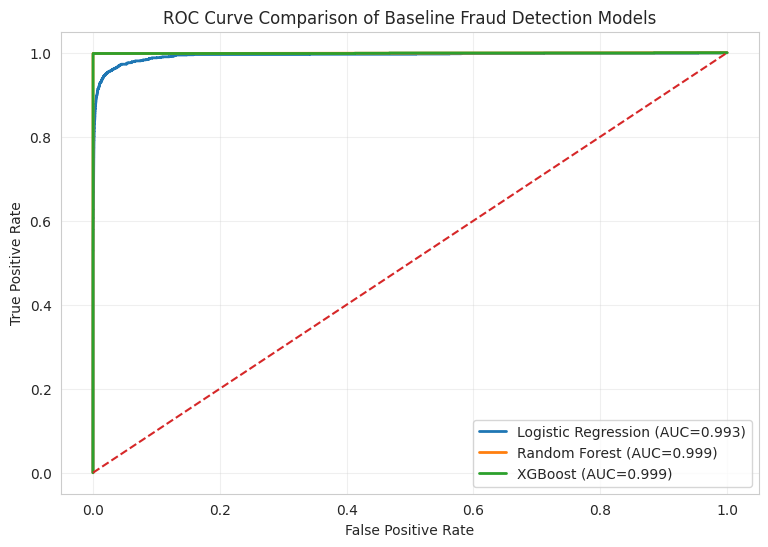

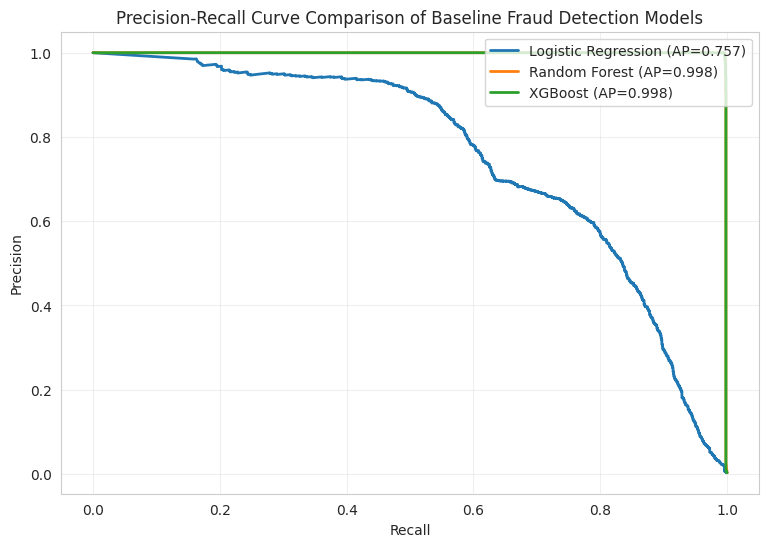

In [60]:
# =============================================================================
# ROC Curve and Precision-Recall Curve
# Baseline Models Only
# Logistic Regression, Random Forest, XGBoost
# =============================================================================

import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)


# Store baseline model probabilities

baseline_models = {

    "Logistic Regression": lr_prob,

    "Random Forest": rf_prob,

    "XGBoost": xgb_prob

}



# =============================================================================
# 1. ROC Curve Comparison - Baseline Models
# =============================================================================


plt.figure(figsize=(9,6))


for name, prob in baseline_models.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        prob
    )


    roc_auc = auc(
        fpr,
        tpr
    )


    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC={roc_auc:.3f})"
    )


# Random classifier reference

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)



plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.title(
    "ROC Curve Comparison of Baseline Fraud Detection Models"
)


plt.legend(
    loc="lower right"
)


plt.grid(
    alpha=0.3
)


plt.show()




# =============================================================================
# 2. Precision-Recall Curve Comparison - Baseline Models
# =============================================================================


plt.figure(figsize=(9,6))


for name, prob in baseline_models.items():


    precision, recall, _ = precision_recall_curve(

        y_test,

        prob

    )


    pr_auc = average_precision_score(

        y_test,

        prob

    )


    plt.plot(

        recall,

        precision,

        linewidth=2,

        label=f"{name} (AP={pr_auc:.3f})"

    )



plt.xlabel(
    "Recall"
)


plt.ylabel(
    "Precision"
)


plt.title(
    "Precision-Recall Curve Comparison of Baseline Fraud Detection Models"
)


plt.legend(
    loc="upper right"
)


plt.grid(
    alpha=0.3
)


plt.show()

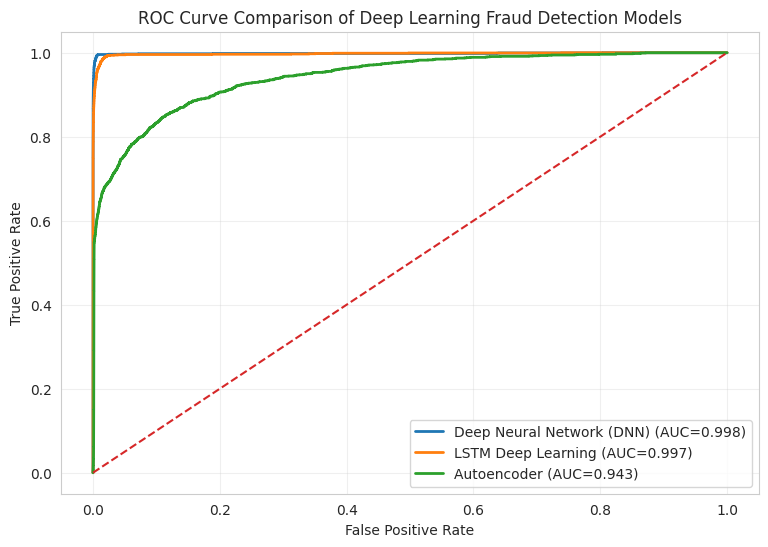

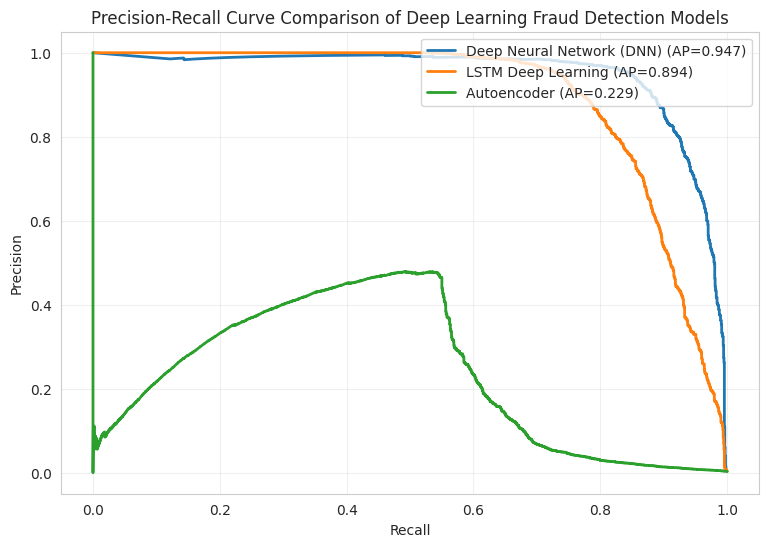

In [61]:
# =============================================================================
# ROC Curve and Precision-Recall Curve
# Deep Learning Models Only
# DNN, LSTM, Autoencoder
# =============================================================================

import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)


# Store deep learning model probabilities

deep_models = {

    "Deep Neural Network (DNN)": dnn_prob,

    "LSTM Deep Learning": lstm_prob,

    "Autoencoder": ae_prob

}



# =============================================================================
# 1. ROC Curve Comparison - Deep Learning Models
# =============================================================================

plt.figure(figsize=(9,6))


for name, prob in deep_models.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        prob
    )


    roc_auc = auc(
        fpr,
        tpr
    )


    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC={roc_auc:.3f})"
    )



plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)


plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.title(
    "ROC Curve Comparison of Deep Learning Fraud Detection Models"
)


plt.legend(
    loc="lower right"
)


plt.grid(
    alpha=0.3
)


plt.show()




# =============================================================================
# 2. Precision-Recall Curve Comparison - Deep Learning Models
# =============================================================================

plt.figure(figsize=(9,6))


for name, prob in deep_models.items():

    precision, recall, _ = precision_recall_curve(
        y_test,
        prob
    )


    ap_score = average_precision_score(
        y_test,
        prob
    )


    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{name} (AP={ap_score:.3f})"
    )



plt.xlabel(
    "Recall"
)


plt.ylabel(
    "Precision"
)


plt.title(
    "Precision-Recall Curve Comparison of Deep Learning Fraud Detection Models"
)


plt.legend(
    loc="upper right"
)


plt.grid(
    alpha=0.3
)


plt.show()

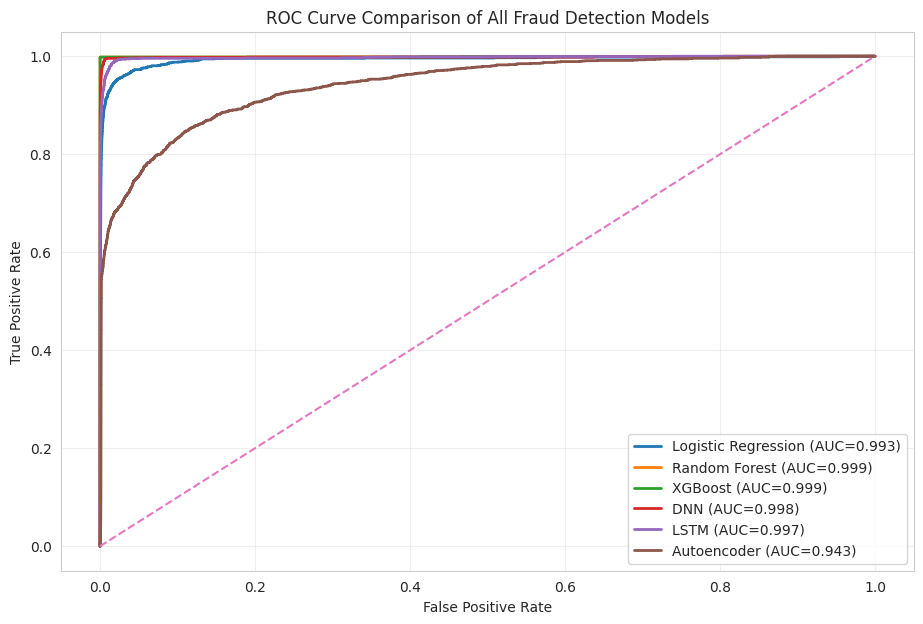

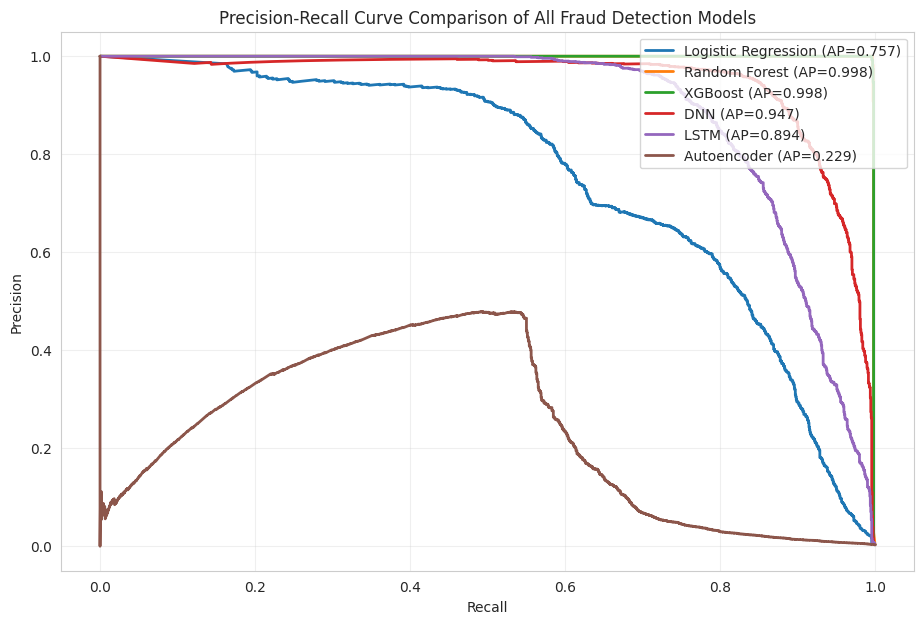

In [62]:
# =============================================================================
# Combine All Model Predictions
# =============================================================================

all_models = {

    "Logistic Regression": lr_prob,

    "Random Forest": rf_prob,

    "XGBoost": xgb_prob,

    "DNN": dnn_prob,

    "LSTM": lstm_prob,

    "Autoencoder": ae_prob

}



# =============================================================================
# 1. ROC Curve Comparison - All Models
# =============================================================================

plt.figure(figsize=(11,7))


for name, prob in all_models.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        prob
    )


    roc_auc = auc(
        fpr,
        tpr
    )


    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC={roc_auc:.3f})"
    )



# Random classifier line

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)



plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.title(
    "ROC Curve Comparison of All Fraud Detection Models"
)


plt.legend(
    loc="lower right"
)


plt.grid(
    alpha=0.3
)


plt.show()




# =============================================================================
# 2. Precision-Recall Curve Comparison - All Models
# =============================================================================

plt.figure(figsize=(11,7))


for name, prob in all_models.items():


    precision, recall, _ = precision_recall_curve(

        y_test,

        prob

    )


    ap_score = average_precision_score(

        y_test,

        prob

    )


    plt.plot(

        recall,

        precision,

        linewidth=2,

        label=f"{name} (AP={ap_score:.3f})"

    )



plt.xlabel(
    "Recall"
)


plt.ylabel(
    "Precision"
)


plt.title(
    "Precision-Recall Curve Comparison of All Fraud Detection Models"
)


plt.legend(
    loc="upper right"
)


plt.grid(
    alpha=0.3
)


plt.show()

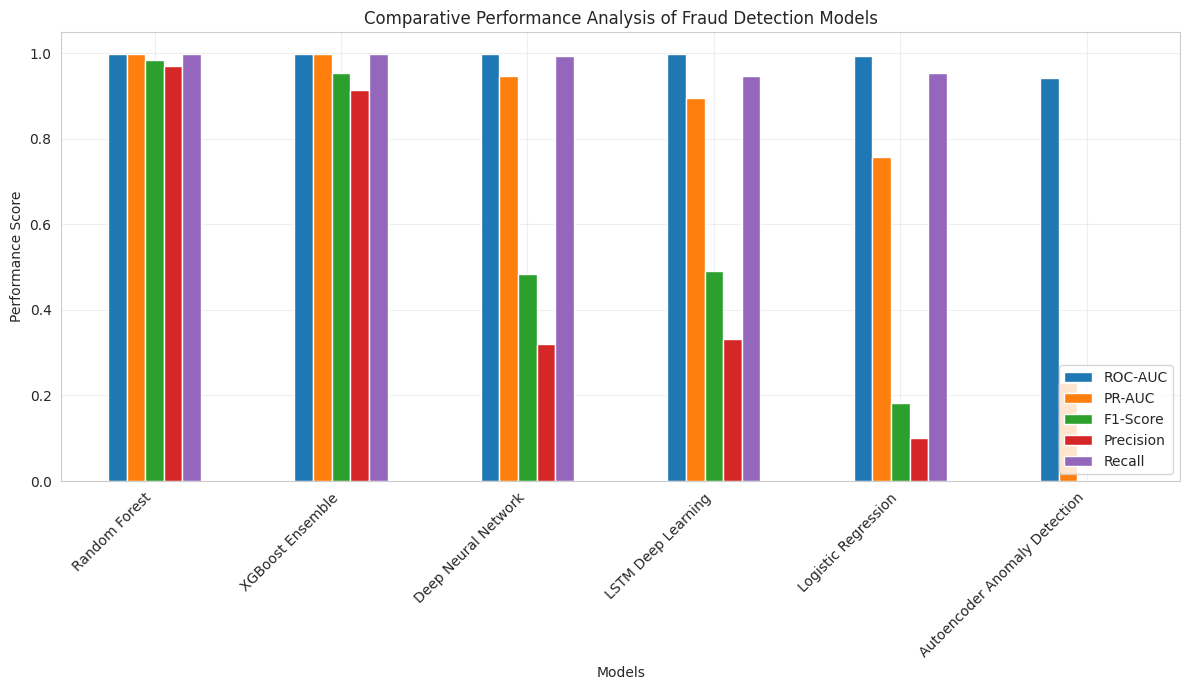

In [59]:
# =============================================================================
# 3. Comparative Performance Visualisation
# =============================================================================


comparison_metrics = results_df[

    [

        "ROC-AUC",

        "PR-AUC",

        "F1-Score",

        "Precision",

        "Recall"

    ]

]



comparison_metrics.plot(

    kind="bar",

    figsize=(12,7)

)



plt.title(

    "Comparative Performance Analysis of Fraud Detection Models"

)



plt.ylabel(

    "Performance Score"

)



plt.xlabel(

    "Models"

)



plt.xticks(

    rotation=45,

    ha="right"

)



plt.legend(

    loc="lower right"

)



plt.grid(

    alpha=0.3

)



plt.tight_layout()


plt.show()

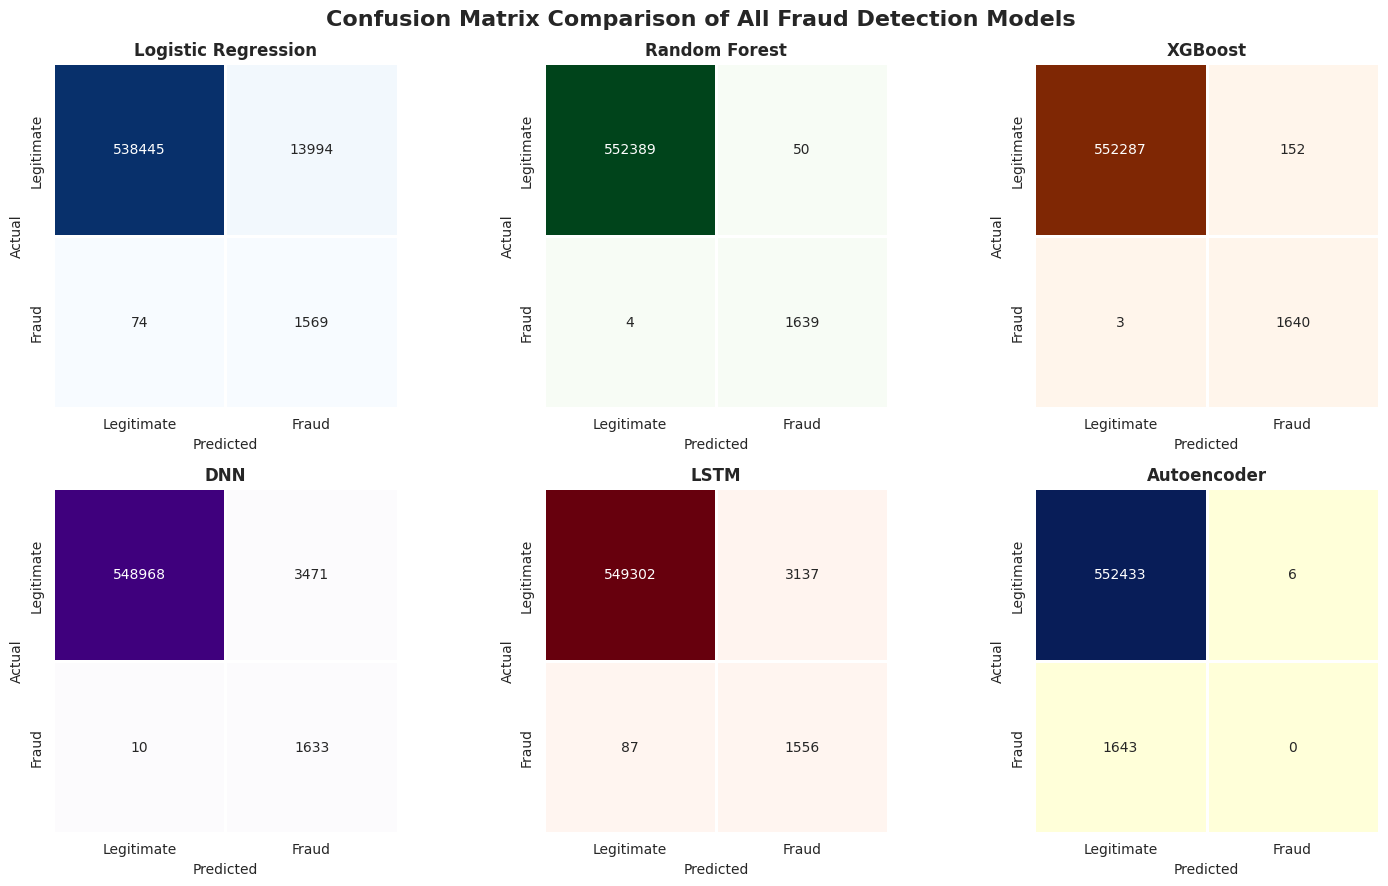

In [64]:
# =============================================================================
# Side-by-Side Confusion Matrix Plot - All Models
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix



# Predictions from all models

all_model_predictions = {

    "Logistic Regression":
        (lr_prob >= 0.5).astype(int),

    "Random Forest":
        (rf_prob >= 0.5).astype(int),

    "XGBoost":
        (xgb_prob >= 0.5).astype(int),

    "DNN":
        (dnn_prob >= 0.5).astype(int),

    "LSTM":
        (lstm_prob >= 0.5).astype(int),

    "Autoencoder":
        (ae_prob >= 0.5).astype(int)

}



# Different colour pairs

cmaps = [
    "Blues",
    "Greens",
    "Oranges",
    "Purples",
    "Reds",
    "YlGnBu"
]



# Create side-by-side layout

fig, axes = plt.subplots(

    2,

    3,

    figsize=(15,9)

)



axes = axes.flatten()



for ax, (model, prediction), cmap in zip(

    axes,

    all_model_predictions.items(),

    cmaps

):


    cm = confusion_matrix(

        y_test,

        prediction

    )


    sns.heatmap(

        cm,

        annot=True,

        fmt="d",

        cmap=cmap,

        cbar=False,

        linewidths=1,

        square=True,

        ax=ax

    )


    ax.set_title(

        model,

        fontsize=12,

        fontweight="bold"

    )


    ax.set_xlabel(

        "Predicted"

    )


    ax.set_ylabel(

        "Actual"

    )


    ax.set_xticklabels(

        ["Legitimate","Fraud"],

        rotation=0

    )


    ax.set_yticklabels(

        ["Legitimate","Fraud"],

        rotation=90

    )



plt.suptitle(

    "Confusion Matrix Comparison of All Fraud Detection Models",

    fontsize=16,

    fontweight="bold"

)


plt.tight_layout()


plt.show()

## 8. 5-Fold Stratified Cross-Validation

Cross-validation is performed on the under-sampled training partition (the test set remains fully held out) for the three strongest candidate models: Random Forest, XGBoost, and the Hybrid Fusion model.

In [65]:
# =============================================================================
# 5-Fold Stratified Cross-Validation
# Financial Fraud Detection Models
# =============================================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier



# =============================================================================
# Define Models
# =============================================================================


fraud_weight = (
    (y_train == 0).sum()
    /
    (y_train == 1).sum()
)



cv_models = {


    "Logistic Regression":

    LogisticRegression(

        max_iter=500,

        class_weight="balanced",

        random_state=42

    ),



    "Random Forest":

    RandomForestClassifier(

        n_estimators=200,

        max_depth=15,

        class_weight="balanced_subsample",

        n_jobs=-1,

        random_state=42

    ),



    "XGBoost":

    XGBClassifier(

        n_estimators=300,

        max_depth=6,

        learning_rate=0.1,

        subsample=0.8,

        colsample_bytree=0.8,

        eval_metric="auc",

        tree_method="hist",

        scale_pos_weight=fraud_weight,

        random_state=42

    )

}




# =============================================================================
# Stratified 5-Fold Cross Validation Setup
# =============================================================================


stratified_cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)



cv_results = {}



# =============================================================================
# Model Evaluation Using ROC-AUC
# =============================================================================


for name, model in cv_models.items():


    scores = cross_val_score(

        model,

        X_train,

        y_train,

        cv=stratified_cv,

        scoring="roc_auc",

        n_jobs=-1

    )


    cv_results[name] = {


        "Fold 1": scores[0],

        "Fold 2": scores[1],

        "Fold 3": scores[2],

        "Fold 4": scores[3],

        "Fold 5": scores[4],


        "Mean ROC-AUC":

        scores.mean(),


        "Std ROC-AUC":

        scores.std()

    }


    print(

        f"{name}: "

        f"Mean ROC-AUC = {scores.mean():.4f} "

        f"(±{scores.std():.4f})"

    )




# =============================================================================
# Cross Validation Results Table
# =============================================================================


cv_results_df = pd.DataFrame(

    cv_results

).T



cv_results_df

Logistic Regression: Mean ROC-AUC = 0.9862 (±0.0021)
Random Forest: Mean ROC-AUC = 0.9993 (±0.0007)
XGBoost: Mean ROC-AUC = 0.9995 (±0.0004)


,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean ROC-AUC,Std ROC-AUC
Logistic Regression,0.982332,0.988809,0.986000,0.986773,0.987149,0.986213,0.002146
Random Forest,0.998759,0.999925,0.999537,0.998353,0.999994,0.999314,0.000651
XGBoost,0.999170,0.999822,0.999428,0.998976,0.999997,0.999479,0.000384


## 9. Statistical Significance Testing



In [66]:
# =============================================================================
# Statistical Significance Testing
# Paired t-test on 5-Fold Stratified Cross-Validation ROC-AUC Scores
# =============================================================================

from scipy.stats import ttest_rel
import pandas as pd



# =============================================================================
# Collect Cross-Validation Scores for Each Model
# =============================================================================

model_cv_scores = {}



for name, model in cv_models.items():

    scores = cross_val_score(

        model,

        X_train,

        y_train,

        cv=stratified_cv,

        scoring="roc_auc",

        n_jobs=-1

    )

    model_cv_scores[name] = scores




# Convert to DataFrame

cv_score_table = pd.DataFrame(

    model_cv_scores

)



print("5-Fold ROC-AUC Scores")

print(cv_score_table)




# =============================================================================
# Pairwise Statistical Significance Test
# =============================================================================


statistical_results = []



models = list(model_cv_scores.keys())



for i in range(len(models)):

    for j in range(i+1, len(models)):


        model_1 = models[i]

        model_2 = models[j]



        t_stat, p_value = ttest_rel(

            model_cv_scores[model_1],

            model_cv_scores[model_2]

        )


        significance = (

            "Significant"

            if p_value < 0.05

            else

            "Not Significant"

        )



        statistical_results.append({


            "Model 1":

            model_1,


            "Model 2":

            model_2,


            "t-statistic":

            t_stat,


            "p-value":

            p_value,


            "Result":

            significance

        })




# =============================================================================
# Statistical Test Results Table
# =============================================================================


significance_df = pd.DataFrame(

    statistical_results

)



print("\nPairwise Statistical Significance Results")

significance_df

5-Fold ROC-AUC Scores
   Logistic Regression  Random Forest   XGBoost
0             0.982332       0.998759  0.999170
1             0.988809       0.999925  0.999822
2             0.986000       0.999537  0.999428
3             0.986773       0.998353  0.998976
4             0.987149       0.999994  0.999997

Pairwise Statistical Significance Results


,Model 1,Model 2,t-statistic,p-value,Result
0,Logistic Regression,Random Forest,-13.979095,0.000152,Significant
1,Logistic Regression,XGBoost,-13.553473,0.000172,Significant
2,Random Forest,XGBoost,-1.108316,0.329876,Not Significant


## 10. Explainability — SHAP Analysis

SHAP Feature Importance Ranking


<Figure size 1000x600 with 0 Axes>

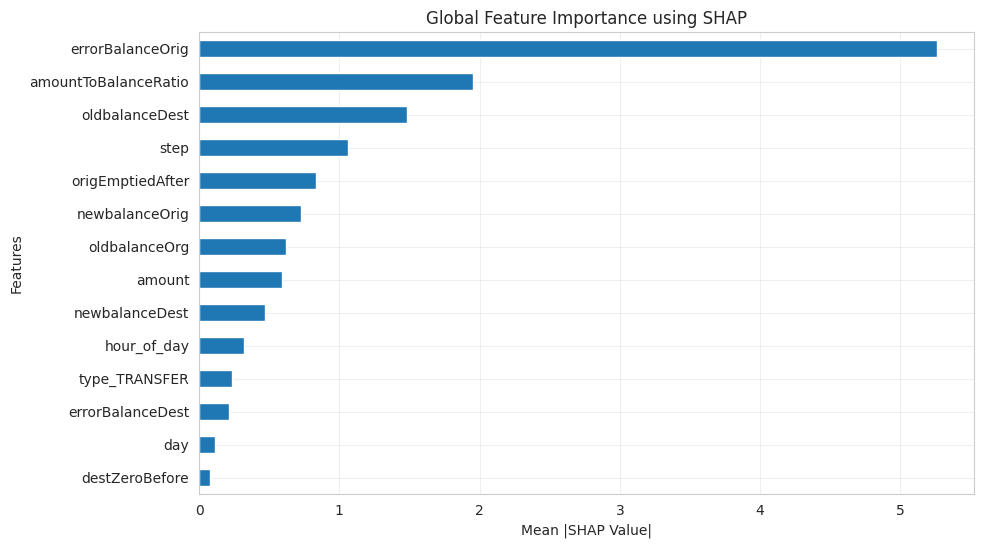

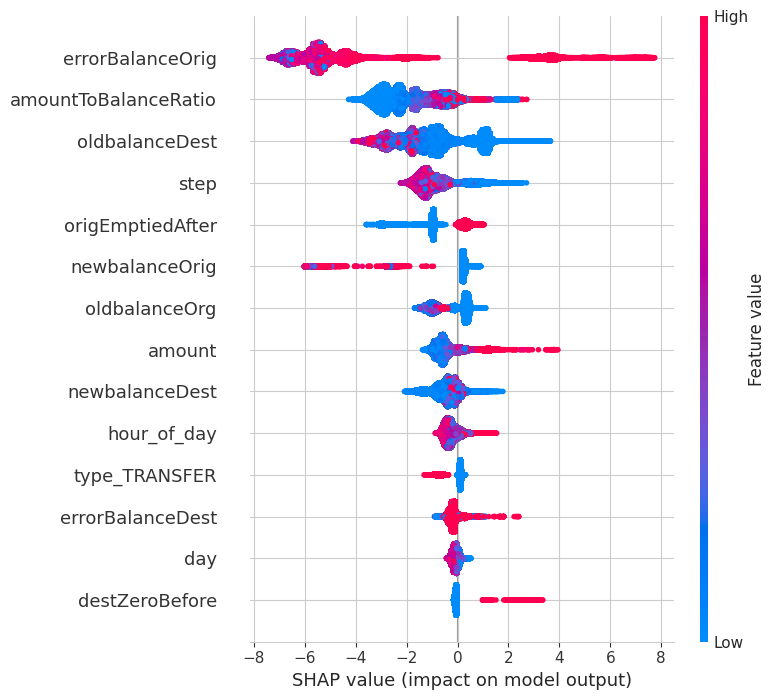

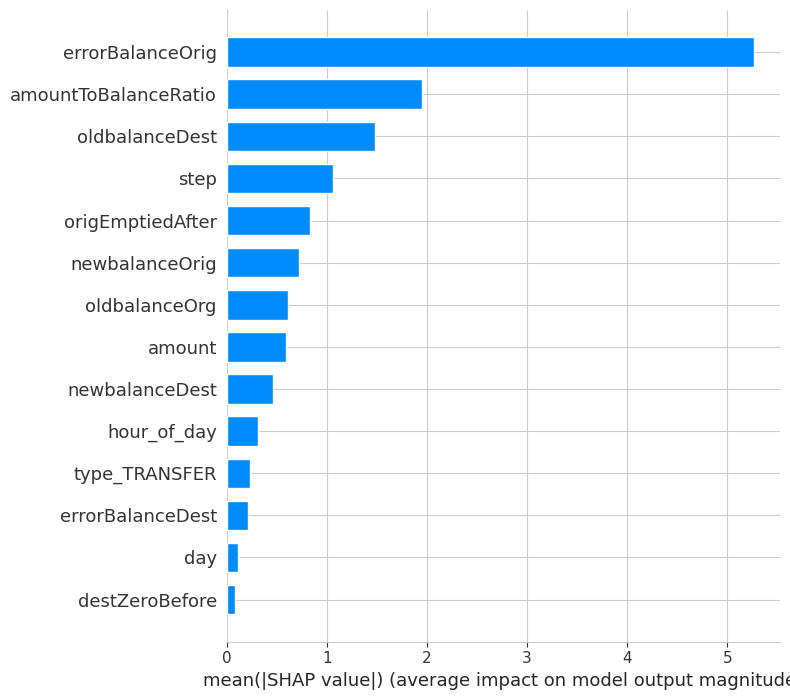

In [68]:
# =============================================================================
# Explainable Artificial Intelligence (XAI)
# SHAP Analysis using XGBoost Fraud Detection Model
# =============================================================================


# Install if required
# !pip install shap


import shap
import matplotlib.pyplot as plt



# =============================================================================
# 1. Create SHAP Explainer
# =============================================================================


explainer = shap.TreeExplainer(

    xgb_model

)



# Calculate SHAP values

shap_values = explainer.shap_values(

    X_test

)



# =============================================================================
# 2. Global Feature Importance (Mean Absolute SHAP Value)
# =============================================================================


shap_importance = pd.DataFrame({

    "Feature":

    X_test.columns,


    "SHAP Importance":

    np.abs(shap_values).mean(axis=0)

})



shap_importance = shap_importance.sort_values(

    by="SHAP Importance",

    ascending=False

)



print(
    "SHAP Feature Importance Ranking"
)


shap_importance




# =============================================================================
# 3. SHAP Feature Importance Bar Plot
# =============================================================================


plt.figure(

    figsize=(10,6)

)


shap_importance.plot(

    x="Feature",

    y="SHAP Importance",

    kind="barh",

    figsize=(10,6),

    legend=False

)



plt.gca().invert_yaxis()


plt.xlabel(

    "Mean |SHAP Value|"

)


plt.ylabel(

    "Features"

)


plt.title(

    "Global Feature Importance using SHAP"

)


plt.grid(

    alpha=0.3

)


plt.show()




# =============================================================================
# 4. SHAP Summary Plot
# Shows Feature Impact Direction
# =============================================================================


shap.summary_plot(

    shap_values,

    X_test,

    plot_type="dot"

)




# =============================================================================
# 5. SHAP Summary Bar Plot
# =============================================================================


shap.summary_plot(

    shap_values,

    X_test,

    plot_type="bar"

)






In [77]:
# =============================================================================
# COMPLETE REAL-TIME HYBRID FRAUD DETECTION GUI
# XGBoost + Autoencoder + Hybrid Fusion
# =============================================================================


import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression

from IPython.display import display
import ipywidgets as widgets



# =============================================================================
# 1. CREATE HYBRID FUSION MODEL
# =============================================================================


# XGBoost prediction score

xgb_train_prob = xgb_model.predict_proba(
    X_train
)[:,1]



# Autoencoder reconstruction score

X_train_reconstructed = autoencoder.predict(
    X_train_scaled
)


train_error = np.mean(

    (X_train_scaled - X_train_reconstructed)**2,

    axis=1

)



ae_train_prob = (

    train_error - train_error.min()

) / (

    train_error.max()

    -

    train_error.min()

    +

    1e-12

)



# Hybrid feature vector

hybrid_train = np.column_stack(

    [

        xgb_train_prob,

        ae_train_prob

    ]

)



# Meta classifier

hybrid_model = LogisticRegression(

    random_state=42

)


hybrid_model.fit(

    hybrid_train,

    y_train

)



print(
    "Hybrid Fusion Model Ready"
)




# =============================================================================
# 2. REAL-TIME FRAUD PREDICTION FUNCTION
# =============================================================================


def real_time_fraud_detection(transaction):


    df = pd.DataFrame(

        [transaction]

    )



    # Feature Engineering

    df["errorBalanceOrig"] = (

        df["oldbalanceOrg"]

        -

        df["amount"]

        -

        df["newbalanceOrig"]

    )



    df["errorBalanceDest"] = (

        df["oldbalanceDest"]

        +

        df["amount"]

        -

        df["newbalanceDest"]

    )



    df["origEmptiedAfter"] = (

        (df["oldbalanceOrg"] > 0)

        &

        (df["newbalanceOrig"] == 0)

    ).astype(int)



    df["destZeroBefore"] = (

        (df["oldbalanceDest"] == 0)

        &

        (df["newbalanceDest"] == 0)

    ).astype(int)



    df["amountToBalanceRatio"] = (

        df["amount"]

        /

        (df["oldbalanceOrg"] + 1)

    )



    # Arrange same features as training

    X_new = df[X_train.columns]



    # -----------------------------
    # XGBoost prediction
    # -----------------------------

    xgb_score = xgb_model.predict_proba(

        X_new

    )[:,1]



    # -----------------------------
    # Autoencoder anomaly
    # -----------------------------

    X_new_scaled = scaler.transform(

        X_new

    )


    reconstructed = autoencoder.predict(

        X_new_scaled

    )


    error = np.mean(

        (X_new_scaled - reconstructed)**2,

        axis=1

    )



    ae_score = (

        error - train_error.min()

    ) / (

        train_error.max()

        -

        train_error.min()

        +

        1e-12

    )



    # -----------------------------
    # Hybrid prediction
    # -----------------------------

    hybrid_input = np.column_stack(

        [

            xgb_score,

            ae_score

        ]

    )


    hybrid_probability = hybrid_model.predict_proba(

        hybrid_input

    )[:,1][0]



    if hybrid_probability >= 0.5:

        decision = "Fraudulent Transaction"

    else:

        decision = "Legitimate Transaction"



    return {


        "XGBoost Score":

        round(float(xgb_score[0]),4),



        "Autoencoder Score":

        round(float(ae_score[0]),4),



        "Hybrid Probability":

        round(float(hybrid_probability),4),



        "Decision":

        decision

    }





# =============================================================================
# 3. SIMPLE COLAB GUI
# =============================================================================


step = widgets.FloatText(
    value=500,
    description="Step:"
)


type_TRANSFER = widgets.IntText(
    value=1,
    description="Type:"
)


amount = widgets.FloatText(
    value=250000,
    description="Amount:"
)


oldbalanceOrg = widgets.FloatText(
    value=300000,
    description="Old Org:"
)


newbalanceOrig = widgets.FloatText(
    value=50000,
    description="New Org:"
)


oldbalanceDest = widgets.FloatText(
    value=0,
    description="Old Dest:"
)


newbalanceDest = widgets.FloatText(
    value=250000,
    description="New Dest:"
)


hour = widgets.IntText(
    value=10,
    description="Hour:"
)


day = widgets.IntText(
    value=21,
    description="Day:"
)



button = widgets.Button(

    description="Detect Fraud",

    button_style="danger"

)



output = widgets.Output()




def detect(button):

    with output:

        output.clear_output()


        transaction = {


            "step":step.value,


            "type_TRANSFER":type_TRANSFER.value,


            "amount":amount.value,


            "oldbalanceOrg":oldbalanceOrg.value,


            "newbalanceOrig":newbalanceOrig.value,


            "oldbalanceDest":oldbalanceDest.value,


            "newbalanceDest":newbalanceDest.value,


            "hour_of_day":hour.value,


            "day":day.value

        }



        result = real_time_fraud_detection(

            transaction

        )



        print("==============================")

        print("REAL-TIME FRAUD RESULT")

        print("==============================")

        print()

        print(
            "XGBoost Score:",
            result["XGBoost Score"]
        )


        print(
            "Autoencoder Score:",
            result["Autoencoder Score"]
        )


        print(
            "Hybrid Probability:",
            result["Hybrid Probability"]
        )


        print()

        print(
            "Decision:",
            result["Decision"]
        )

        print("==============================")




button.on_click(

    detect

)



display(

    step,

    type_TRANSFER,

    amount,

    oldbalanceOrg,

    newbalanceOrig,

    oldbalanceDest,

    newbalanceDest,

    hour,

    day,

    button,

    output

)

Hybrid Fusion Model Ready


FloatText(value=500.0, description='Step:')

IntText(value=1, description='Type:')

FloatText(value=250000.0, description='Amount:')

FloatText(value=300000.0, description='Old Org:')

...

FloatText(value=250000.0, description='New Dest:')

IntText(value=10, description='Hour:')

IntText(value=21, description='Day:')

Button(button_style='danger', description='Detect Fraud', style=ButtonStyle())

Output()